# Depth & Tilt — Sign Size Estimation

รวม Depth_SizeEstimation (calibration) + TiltSign_SizeEstimation (RANSAC + foreshortening)
ประเมินขนาดป้าย แล้วแสดงผล **ก่อน vs หลัง calibration** (calibrate หลังขั้นแก้ป้ายเอียง)


## 0. ติดตั้ง OpenCV (ครั้งเดียวต่อ session)

In [1]:
%pip install -q opencv-python

## 1. Setup — Depth Pro + (dual-mode Colab/local)

บน Colab: mount Drive, clone Depth Pro, ดาวน์โหลด checkpoint ให้อัตโนมัติ

In [2]:
import os, sys, subprocess
from pathlib import Path

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print('Environment:', 'Google Colab' if IN_COLAB else 'local / VS Code')

DRIVE_OK = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive'); DRIVE_OK = True
    except Exception as e:
        print('WARNING mount Drive:', str(e).splitlines()[0][:140])
    DEPTH_PRO_DIR = Path('/content/ml-depth-pro')
    if not DEPTH_PRO_DIR.exists():
        print('Cloning apple/ml-depth-pro ...')
        subprocess.run(['git','clone','https://github.com/apple/ml-depth-pro.git', str(DEPTH_PRO_DIR)], check=True)
    _pip = [sys.executable,'-m','pip','install','-q']
    subprocess.run(_pip + ['-e', str(DEPTH_PRO_DIR), '--no-deps'], check=True)
    subprocess.run(_pip + ['timm','pillow_heif'], check=True)
    subprocess.run(_pip + ['numpy>=2'], check=True)
    DEPTH_CKPT = DEPTH_PRO_DIR/'checkpoints'/'depth_pro.pt'
    if not DEPTH_CKPT.exists():
        print('Downloading Depth Pro checkpoint (~1.9GB) ...')
        DEPTH_CKPT.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(['wget','-q','--show-progress',
                        'https://ml-site.cdn-apple.com/models/depth-pro/depth_pro.pt',
                        '-O', str(DEPTH_CKPT)], check=True)
    import importlib.metadata as _md
    _np = sys.modules.get('numpy')
    if _np is not None and getattr(_np,'__version__','') != _md.version('numpy'):
        raise RuntimeError('NumPy เปลี่ยนเวอร์ชัน -> RESTART KERNEL แล้ว Run all ใหม่')
    print('Depth Pro ready:', DEPTH_CKPT.exists())
else:
    DEPTH_PRO_DIR = Path('depth-pro')
    DEPTH_CKPT = DEPTH_PRO_DIR/'checkpoints'/'depth_pro.pt'
print('Setup OK. Drive mounted:', DRIVE_OK)

Mounted at /content/drive
Cloning apple/ml-depth-pro ...
Depth Pro ready: True
Setup OK. Drive mounted: True


## 2. Config — paths + พารามิเตอร์

แก้ path ให้ตรงกับที่เก็บไฟล์ (Colab อ่านจาก MyDrive)

In [3]:
from pathlib import Path

if IN_COLAB:
    DRIVE = Path('/content/drive/MyDrive')
    TEST_DIR       = DRIVE/'coco-dataset'/'test'
    DETECTOR_CKPT  = DRIVE/'fasterrcnn_resnet101_finetuned_no_resize.pth'
    REAL_SIZES_CSV = DRIVE/'real_sizes.csv'
else:
    TEST_DIR       = Path('coco-dataset/test')
    DETECTOR_CKPT  = Path('fasterrcnn_resnet101_finetuned_no_resize.pth')
    REAL_SIZES_CSV = Path('real_sizes.csv')

# พารามิเตอร์
DEPTH_BAND      = 0.15     # ความหนาย่านความลึกของ depth-mask (เมตร)
MORPH_KSIZE     = 7        # kernel ปิดรู/ลบ noise ของ mask
SCORE_THRESH    = 0.5      # threshold ความมั่นใจของ detector
CENTER_FRACTION = 0.5      # โซนกลางของกล่องที่ใช้หา Z
CLASS_NAMES     = ['__background__', 'sign']

print('TEST_DIR      :', TEST_DIR, '| exists', TEST_DIR.exists())
print('Detector ckpt :', DETECTOR_CKPT.exists())
print('Depth ckpt    :', DEPTH_CKPT.exists())
print('real_sizes.csv:', REAL_SIZES_CSV.exists())

TEST_DIR      : /content/drive/MyDrive/coco-dataset/test | exists True
Detector ckpt : True
Depth ckpt    : True
real_sizes.csv: True


## 3. โหลด Depth Pro + import

In [4]:
import numpy as np, cv2, torch, gc
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    from depth_pro import load_rgb, create_model_and_transforms
    from depth_pro.depth_pro import DEFAULT_MONODEPTH_CONFIG_DICT
except ImportError:
    sys.path.insert(0, str((DEPTH_PRO_DIR/'src').resolve()))
    from depth_pro import load_rgb, create_model_and_transforms
    from depth_pro.depth_pro import DEFAULT_MONODEPTH_CONFIG_DICT


def _load_depth(device):
    cfg = DEFAULT_MONODEPTH_CONFIG_DICT
    cfg.checkpoint_uri = str(Path(DEPTH_CKPT).resolve())
    m, t = create_model_and_transforms(config=cfg, device=device, precision=torch.float32)
    m.eval()
    return m, t


# เคลียร์ cache + รายงาน GPU ว่าง
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        free, total = torch.cuda.mem_get_info()
        print(f'GPU ว่าง {free/1e9:.2f} / {total/1e9:.2f} GB')
    except Exception:
        pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Loading Depth Pro on', DEVICE, '...')
try:
    depth_model, depth_transform = _load_depth(DEVICE)
except RuntimeError as e:
    if 'out of memory' in str(e).lower() or 'cuda' in str(e).lower():
        print('⚠️ GPU เต็ม -> ใช้ CPU แทน (ช้าแต่รันได้)')
        print('   อยากให้เร็ว: ไป Runtime > Manage sessions แล้ว Terminate เคอร์เนล notebook อื่น หรือ Restart session')
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        DEVICE = torch.device('cpu')
        depth_model, depth_transform = _load_depth(DEVICE)
    else:
        raise
print('Depth Pro loaded on', DEVICE)


GPU ว่าง 15.53 / 15.64 GB
Loading Depth Pro on cuda ...
Depth Pro loaded on cuda


## 4. โหลด Faster R-CNN (detector ป้าย)

In [5]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import gc

assert DETECTOR_CKPT.exists(), f'ไม่พบ detector checkpoint: {DETECTOR_CKPT} (อัปโหลดเข้า Drive)'
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()


def _load_detector(device):
    bb = resnet_fpn_backbone(backbone_name='resnet101', weights=None, trainable_layers=0)
    d = FasterRCNN(bb, num_classes=91)
    inf = d.roi_heads.box_predictor.cls_score.in_features
    d.roi_heads.box_predictor = FastRCNNPredictor(inf, len(CLASS_NAMES))
    d.load_state_dict(torch.load(DETECTOR_CKPT, map_location=device))
    return d.to(device).eval()


try:
    detector = _load_detector(DEVICE)
except RuntimeError as e:
    if 'out of memory' in str(e).lower() or 'cuda' in str(e).lower():
        print('⚠️ GPU เต็ม (detector) -> ใช้ CPU (ย้าย Depth Pro มา CPU ให้ตรงกัน)')
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        DEVICE = torch.device('cpu')
        depth_model.to(DEVICE)
        detector = _load_detector(DEVICE)
    else:
        raise
print('Detector loaded on', DEVICE, ':', CLASS_NAMES)


def detect_sign_box(img_np, score_thresh=SCORE_THRESH):
    '''คืน box (x1,y1,x2,y2) ของ sign ที่ score สูงสุด หรือ None'''
    t = torch.from_numpy(img_np).permute(2, 0, 1).float().div(255.0).to(DEVICE)
    with torch.no_grad():
        det = detector([t])[0]
    sc = det['scores'].cpu().numpy(); bx = det['boxes'].cpu().numpy()
    keep = sc >= score_thresh; bx, sc = bx[keep], sc[keep]
    if len(bx) == 0:
        return None
    return tuple(int(round(v)) for v in bx[sc.argmax()])


Detector loaded on cuda : ['__background__', 'sign']


## 5. ฟังก์ชันหลัก — mask, RANSAC plane, และสูตร Tilt Method

- `depth_to_masks` : depth-band + connected-component → mask ป้าย
- `backproject` : depth → จุด 3D
- `plane_refine` : **RANSAC** หาระนาบป้าย
- `fit_plane` : SVD → normal (มุมเอียง)
- `estimate_size_method4` : รวมทุกอย่างเป็นขนาด (กว้าง×สูง)

In [6]:
def clean_mask(mask):
    k = np.ones((MORPH_KSIZE, MORPH_KSIZE), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    return mask

def depth_to_masks(dm):
    '''depth-band + เก็บก้อนที่ครอบจุดกลาง -> mask ป้าย'''
    h, w = dm.shape
    ref = float(np.median(dm[int(h*0.4):int(h*0.6), int(w*0.4):int(w*0.6)]))
    band = clean_mask((np.abs(dm - ref) < DEPTH_BAND).astype(np.uint8) * 255)
    _, labels = cv2.connectedComponents((band > 0).astype(np.uint8))
    patch = labels[int(h*0.4):int(h*0.6), int(w*0.4):int(w*0.6)]; fg = patch[patch > 0]
    if fg.size:
        seed = int(np.bincount(fg).argmax())
    else:
        allfg = labels[labels > 0]; seed = int(np.bincount(allfg).argmax()) if allfg.size else 0
    cc = (labels == seed).astype(np.uint8) * 255 if seed > 0 else band
    return clean_mask(cc)

def backproject(dm, f_px):
    '''depth (HxW) -> จุด 3D (HxWx3) กล้อง pinhole, principal point = กลางภาพ'''
    h, w = dm.shape; cx, cy = w/2.0, h/2.0
    us, vs = np.meshgrid(np.arange(w), np.arange(h))
    X = (us - cx) * dm / f_px; Y = (vs - cy) * dm / f_px
    return np.stack([X, Y, dm], axis=-1)

def plane_refine(mask, pts3d, thresh=0.02, iters=300, seed=0):
    '''RANSAC ระนาบจากจุดใน mask -> mask ใหม่ (inliers, ก้อนกลาง)'''
    ys, xs = np.where(mask > 0)
    if len(ys) < 50:
        return mask
    P = pts3d[ys, xs]; rng = np.random.default_rng(seed)
    Ps = P if len(P) <= 20000 else P[rng.choice(len(P), 20000, replace=False)]
    best_cnt, best_a, best_n = -1, None, None
    for _ in range(iters):
        a, b, c = Ps[rng.choice(len(Ps), 3, replace=False)]
        nrm = np.cross(b - a, c - a); nn = np.linalg.norm(nrm)
        if nn < 1e-9:
            continue
        nrm = nrm / nn
        cnt = int((np.abs((Ps - a) @ nrm) < thresh).sum())
        if cnt > best_cnt:
            best_cnt, best_a, best_n = cnt, a, nrm
    if best_n is None:
        return mask
    inl = np.abs((P - best_a) @ best_n) < thresh
    refined = np.zeros_like(mask); refined[ys[inl], xs[inl]] = 255
    _, labels = cv2.connectedComponents((refined > 0).astype(np.uint8))
    h, w = mask.shape; fg = labels[int(h*0.4):int(h*0.6), int(w*0.4):int(w*0.6)]; fg = fg[fg > 0]
    if fg.size:
        refined = (labels == int(np.bincount(fg).argmax())).astype(np.uint8) * 255
    return clean_mask(refined)

def fit_plane(P):
    '''SVD -> (จุดบนระนาบ, unit normal)'''
    c = P.mean(axis=0); _, _, vt = np.linalg.svd(P - c, full_matrices=False)
    n = vt[-1]; return c, n / (np.linalg.norm(n) + 1e-12)

def corr_factors(nx, ny, nz):
    '''ตัวแก้ foreshortening = 1/cos(มุมเอียงต่อแกน)'''
    e = 1e-6
    return np.sqrt(nx*nx + nz*nz) / (abs(nz) + e), np.sqrt(ny*ny + nz*nz) / (abs(nz) + e)

def median_center(dm, x1, y1, x2, y2, frac=CENTER_FRACTION):
    '''median depth ในโซนกลาง frac ของกล่อง'''
    h, w = dm.shape; cx, cy = (x1+x2)/2.0, (y1+y2)/2.0
    hw, hh = (x2-x1)*frac/2, (y2-y1)*frac/2
    yy0, yy1 = max(0, int(cy-hh)), min(h, int(cy+hh))
    xx0, xx1 = max(0, int(cx-hw)), min(w, int(cx+hw))
    return float(np.median(dm[yy0:yy1, xx0:xx1]))

def estimate_size_method4(img, return_debug=False):
    '''Tilt Method: pixel+Z = detector box | มุมเอียง(normal) = depth-mask | focal = Depth Pro
       return_debug=True -> แนบ dm/pts3d/m_plane/c_pt ไว้ทำ visualization'''
    with torch.no_grad():
        pred = depth_model.infer(depth_transform(img), f_px=None)
    dm = pred['depth'].detach().cpu().numpy().squeeze()
    f  = float(pred['focallength_px'])
    pts3d = backproject(dm, f)
    m_plane = plane_refine(depth_to_masks(dm), pts3d)        # มุมเอียงจาก depth-mask (RANSAC)
    ys, xs = np.where(m_plane > 0)
    dbg = dict(dm=dm, pts3d=pts3d, m_plane=m_plane) if return_debug else {}
    if len(ys) < 50:
        if return_debug:
            return dict(box=None, tilt=None, Z=None, f=f, W=None, H=None,
                        nx=None, ny=None, nz=None, c_pt=None, **dbg)
        return None
    c_pt, nrm = fit_plane(pts3d[ys, xs])
    nx, ny, nz = float(nrm[0]), float(nrm[1]), float(nrm[2])
    tilt = float(np.degrees(np.arccos(min(1.0, abs(nz)))))
    cw, ch = corr_factors(nx, ny, nz)
    box = detect_sign_box(img)                              # pixel จาก detector
    out = dict(box=box, tilt=tilt, Z=None, f=f, pw=None, ph=None,
               nx=nx, ny=ny, nz=nz, cw=cw, ch=ch, c_pt=c_pt, W=None, H=None)
    if box is not None:
        x1, y1, x2, y2 = box; pw, ph = (x2-x1), (y2-y1)
        Z = median_center(dm, x1, y1, x2, y2)              # Z จาก detector box
        out.update(pw=pw, ph=ph, Z=Z, W=pw*Z/f*cw, H=ph*Z/f*ch)
    out.update(dbg)
    return out


## 6. ประเมินขนาด + Calibration — แสดง 2 output (ก่อน vs หลัง)

รวม pipeline 2 ส่วน:
1. **ขั้นแก้ป้ายเอียง** (จาก TiltSign): detector + Depth Pro + RANSAC plane fitting + foreshortening correction → ได้ขนาด **ก่อน calibration**
2. **Calibration** (จาก Depth_SizeEstimation): หา `K = median(ขนาดจริง / ขนาดทำนาย)` จาก train+valid → คูณกับผล → ได้ขนาด **หลัง calibration**

> calibrate **หลัง**ขั้นแก้ป้ายเอียง — เซลล์จะพิมพ์ขนาด **2 แบบต่อป้าย** (ก่อน/หลัง) + metric เทียบ + รูป 2 ช่องข้างกัน


Calibration factor K = median(true / predicted) = 1.2132   [fit จาก ['train', 'valid'] (62 ป้าย)]

Held-out test: 6 ป้าย
file                     tilt |    GT     | ก่อน calib (raw)      | หลัง calib (x K)
IMG_1374_jpg.rf.3ca96034    4 | 0.28x0.49 | 0.52x0.99 (  93%) | 0.63x1.20 ( 135%)
IMG_1455_jpg.rf.b42d61dc    5 | 1.21x2.32 | 0.64x0.92 (  54%) | 0.77x1.11 (  44%)
IMG_1388_jpg.rf.18c16d0b    8 | 2.34x1.70 | 2.29x1.26 (  14%) | 2.78x1.53 (  14%)
IMG_1244_jpg.rf.bdebc445   13 | 1.20x1.19 | 0.89x0.88 (  26%) | 1.08x1.07 (  10%)
IMG_1338_jpg.rf.b8750a2e   30 | 0.52x0.67 | 0.64x0.92 (  30%) | 0.77x1.12 (  58%)
IMG_1317_jpg.rf.df8c6ec1   36 | 0.49x0.68 | 0.76x1.58 (  94%) | 0.93x1.92 ( 136%)

ก่อน calibration (tilt-corrected ดิบ)  (n=12)
  % within +/-10%:   8.33 %
  RMSE : 0.5740 m  | MAE : 0.4469 m
  MAPE :  51.92 % | R^2 : 0.2850

หลัง calibration (x K)  (n=12)
  % within +/-10%:   8.33 %
  RMSE : 0.6138 m  | MAE : 0.4948 m
  MAPE :  66.14 % | R^2 : 0.1825


/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2567/3713571727.py:123: UserWarning: G

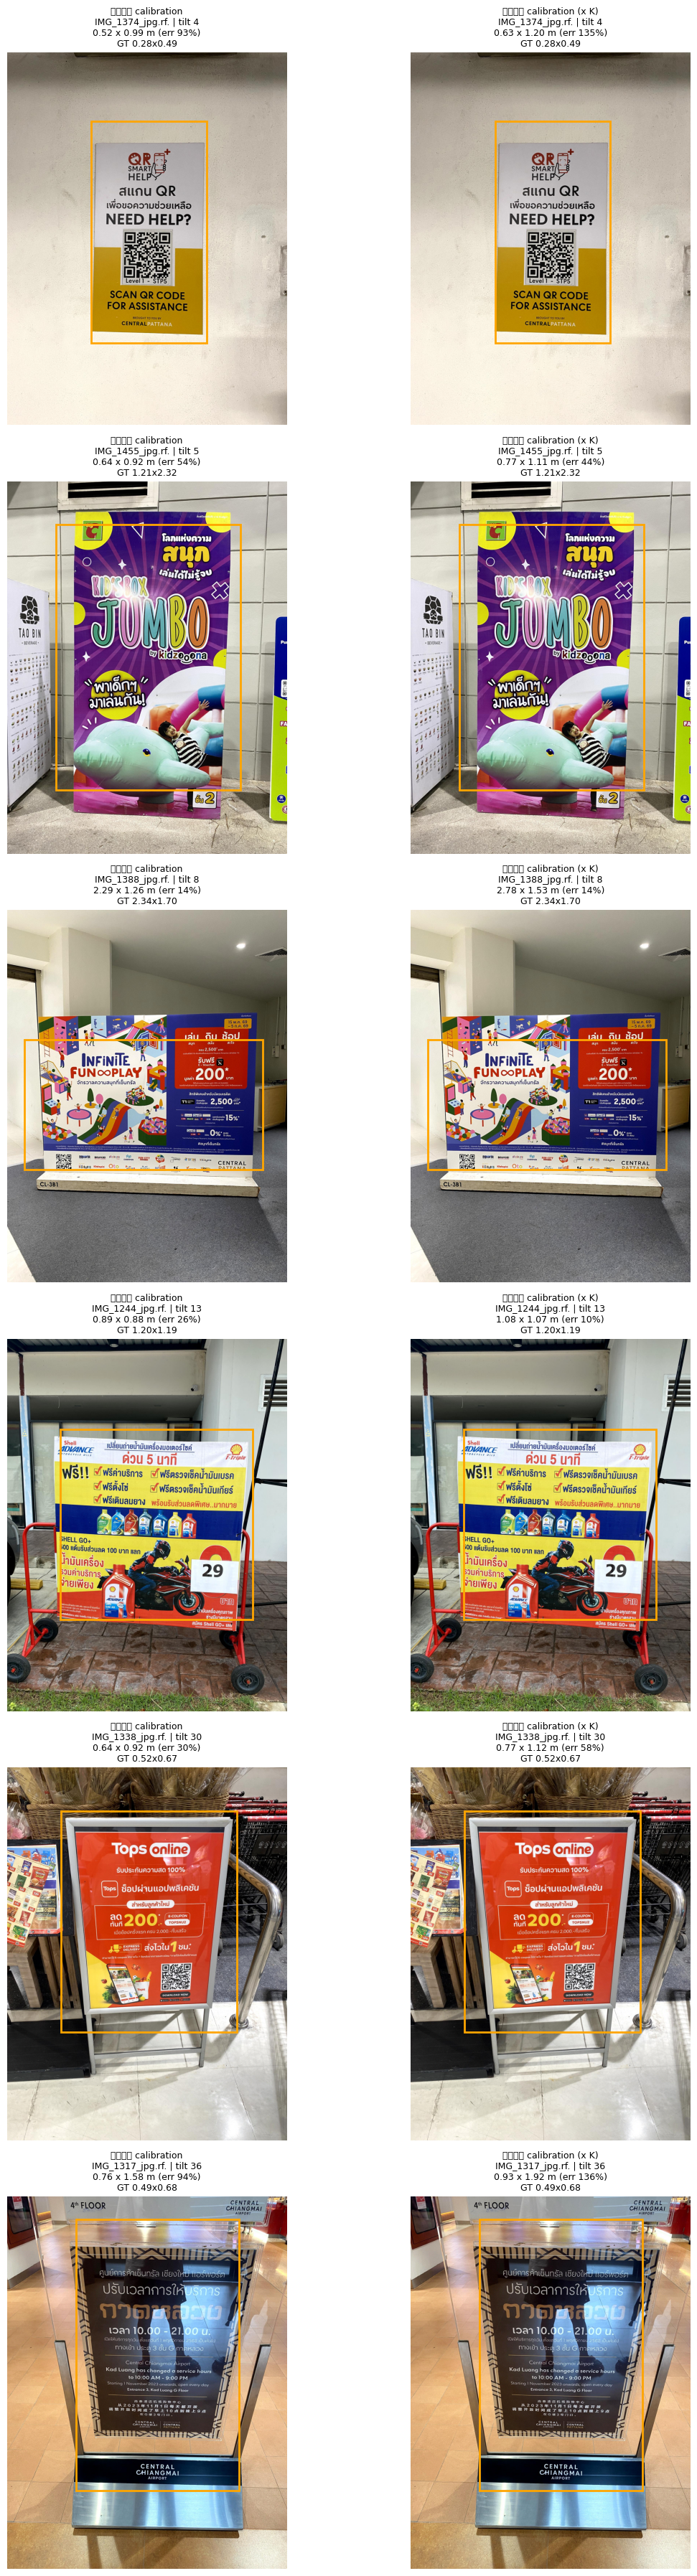

In [7]:
# === ประเมินขนาดป้าย: ก่อน vs หลัง Calibration ===
# pipeline (ก่อน calibration): detector + Depth Pro + RANSAC tilt + foreshortening -> ขนาด
# calibration: คูณ K (fit จาก train+valid) -> ขนาดหลัง calibration
# แสดง 2 output ต่อป้าย: ก่อน calib (raw) และ หลัง calib (x K)
import csv, re
import matplotlib.patches as patches

DATA_ROOT     = TEST_DIR.parent          # coco-dataset (train/valid/test)
CALIB_SPLITS  = ['train', 'valid']       # ใช้ fit K
EVAL_SPLIT    = 'test'                    # held-out วัดผล
ONE_PER_ID    = True
IMG_EXTS      = ('.jpg', '.jpeg', '.png', '.bmp')
TOLERANCE_PCT = 0.10


def img_key(fn):
    m = re.match(r'(IMG_\d+)', fn, re.IGNORECASE)
    return m.group(1).upper() if m else fn.lower()


real_sizes = {}
if REAL_SIZES_CSV.exists():
    with open(REAL_SIZES_CSV, newline='') as fh:
        for row in csv.DictReader(fh):
            real_sizes[img_key(row['filename'].strip())] = (
                float(row['real_width_cm'])/100.0, float(row['real_height_cm'])/100.0)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true; abs_err = np.abs(err)
    mse = float(np.mean(err**2)); rmse = float(np.sqrt(mse)); mae = float(np.mean(abs_err))
    mape = float(np.mean(abs_err/np.abs(y_true))*100.0)
    ss_res = float(np.sum(err**2)); ss_tot = float(np.sum((y_true-y_true.mean())**2))
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else float('nan')
    within = (abs_err/np.abs(y_true)) <= TOLERANCE_PCT
    return dict(n=len(y_true), pct_within=float(np.mean(within)*100), rmse=rmse, mae=mae, mape=mape, r2=r2)


def print_metrics(title, m):
    print(f'\n{title}  (n={m["n"]})')
    print(f'  % within +/-{TOLERANCE_PCT*100:.0f}%: {m["pct_within"]:6.2f} %')
    print(f'  RMSE : {m["rmse"]:.4f} m  | MAE : {m["mae"]:.4f} m')
    print(f'  MAPE : {m["mape"]:6.2f} % | R^2 : {m["r2"]:.4f}')


def collect(split, keep_img=False):
    '''รัน pipeline (ก่อน calibration) บนรูปใน split -> list ของ dict'''
    d = DATA_ROOT / split
    out, seen = [], set()
    if not d.exists():
        print(f'  [warn] ไม่พบ {d}'); return out
    for p in sorted(q for q in d.rglob('*') if q.suffix.lower() in IMG_EXTS):
        key = img_key(p.name)
        if key not in real_sizes or (ONE_PER_ID and key in seen):
            continue
        img, _, _ = load_rgb(str(p))
        r = estimate_size_method4(img)       # tilt-corrected (ก่อน calibration)
        if r is None or r['W'] is None:
            continue
        seen.add(key)
        rec = dict(name=p.name, gt=real_sizes[key], W=r['W'], H=r['H'], tilt=r['tilt'], box=r['box'])
        if keep_img:
            rec['img'] = img
        out.append(rec)
    return out


# --- 1) fit K บน train+valid ---
cal = []
for s in CALIB_SPLITS:
    cal += collect(s)
ratios = []
for r in cal:
    if r['W'] > 0: ratios.append(r['gt'][0]/r['W'])
    if r['H'] > 0: ratios.append(r['gt'][1]/r['H'])
if ratios:
    K = float(np.median(ratios)); src = f'{CALIB_SPLITS} ({len(cal)} ป้าย)'
else:
    print('⚠️ ไม่มี train/valid -> fit K บน test เอง (optimistic)')
    tmp = collect(EVAL_SPLIT); ratios = []
    for r in tmp:
        if r['W'] > 0: ratios.append(r['gt'][0]/r['W'])
        if r['H'] > 0: ratios.append(r['gt'][1]/r['H'])
    K = float(np.median(ratios)) if ratios else 1.0; src = f'{EVAL_SPLIT} (fallback)'
print(f'Calibration factor K = median(true / predicted) = {K:.4f}   [fit จาก {src}]')

# --- 2) eval บน test: ก่อน vs หลัง calibration ---
ev = collect(EVAL_SPLIT, keep_img=True)
ev.sort(key=lambda r: r['tilt'])
ep = lambda pr, gt: abs(pr - gt) / gt * 100

print(f'\nHeld-out {EVAL_SPLIT}: {len(ev)} ป้าย')
print(f'{"file":24s} tilt |    GT     | ก่อน calib (raw)      | หลัง calib (x K)')
yt, yb, ya = [], [], []
for r in ev:
    gt = r['gt']; bw, bh = r['W'], r['H']; aw, ah = r['W']*K, r['H']*K
    yt += [gt[0], gt[1]]; yb += [bw, bh]; ya += [aw, ah]
    eb = (ep(bw, gt[0]) + ep(bh, gt[1]))/2
    ea = (ep(aw, gt[0]) + ep(ah, gt[1]))/2
    print(f"{r['name'][:24]:24s} {r['tilt']:4.0f} | {gt[0]:.2f}x{gt[1]:.2f} | "
          f"{bw:.2f}x{bh:.2f} ({eb:4.0f}%) | {aw:.2f}x{ah:.2f} ({ea:4.0f}%)")

print_metrics('ก่อน calibration (tilt-corrected ดิบ)', regression_metrics(yt, yb))
print_metrics('หลัง calibration (x K)',                 regression_metrics(yt, ya))

# --- 3) gallery 2 ช่อง: [ซ้าย ก่อน calib] [ขวา หลัง calib] ---
n = len(ev)
fig, axes = plt.subplots(n, 2, figsize=(13, 6*n), squeeze=False)
for i, r in enumerate(ev):
    gt = r['gt']
    panels = [('ก่อน calibration', r['W'], r['H']), ('หลัง calibration (x K)', r['W']*K, r['H']*K)]
    for j, (label, W, H) in enumerate(panels):
        ax = axes[i, j]; ax.imshow(r['img'])
        if r['box'] is not None:
            bx = r['box']
            ax.add_patch(patches.Rectangle((bx[0], bx[1]), bx[2]-bx[0], bx[3]-bx[1],
                                           linewidth=2, edgecolor='orange', facecolor='none'))
        e = (ep(W, gt[0]) + ep(H, gt[1]))/2
        ax.set_title(f"{label}\n{r['name'][:16]} | tilt {r['tilt']:.0f}\n"
                     f"{W:.2f} x {H:.2f} m (err {e:.0f}%)\nGT {gt[0]:.2f}x{gt[1]:.2f}", fontsize=9)
        ax.axis('off')
plt.tight_layout(); plt.show()
